<a href="https://colab.research.google.com/github/avanniiii/AvaniAgarwal_102303745_UML501/blob/main/Copy_of_Untitled4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Applications NLP, Computer Vision, IOT (UNC631)

# Assignment - 2


# Submitted by:
#### Name: Dhruv Sood
#### Roll No.: 102315237
#### Sub-Group: 3O32/B


# Submitted to:
#### Dr. Sanjay Sharma


# Fully Automated Artificial Neural Network (ANN) Using Backpropagation


### *Code - Q2(b) Output*


  SELECT MODE
  [1]  Q2(b) demo  — runs Figure 1 automatically
  [2]  Custom ANN  — you define everything interactively

  Enter 1 or 2 : 1

██████████████████████████████████████████████████████████████
  Q2(b) DEMO  :  Architecture  3 → 2 → 2  (Figure 1)
██████████████████████████████████████████████████████████████

  FORWARD PASS  (Step-by-step)

  ── Hidden Layer 1 ──
  net[1][0] = 0.1000·1.0000 + 0.3000·4.0000 + 0.5000·5.0000 + b=0.5000  =  4.300000
  out[1][0] = act(4.300000)  =  0.986613
  net[1][1] = 0.2000·1.0000 + 0.4000·4.0000 + 0.6000·5.0000 + b=0.5000  =  5.300000
  out[1][1] = act(5.300000)  =  0.995033

  ── Output Layer 2 ──
  net[2][0] = 0.7000·0.9866 + 0.9000·0.9950 + b=0.5000  =  2.086159
  out[2][0] = act(2.086159)  =  0.889551
  net[2][1] = 0.8000·0.9866 + 0.1000·0.9950 + b=0.5000  =  1.388794
  out[2][1] = act(1.388794)  =  0.800400

  Predicted : [0.889551 0.8004  ]
  Target    : [0.1  0.05]
  E_out[0]  = 0.5·(0.1000 - 0.889551)²  =  0.31169509
  E_out[1]  = 0.

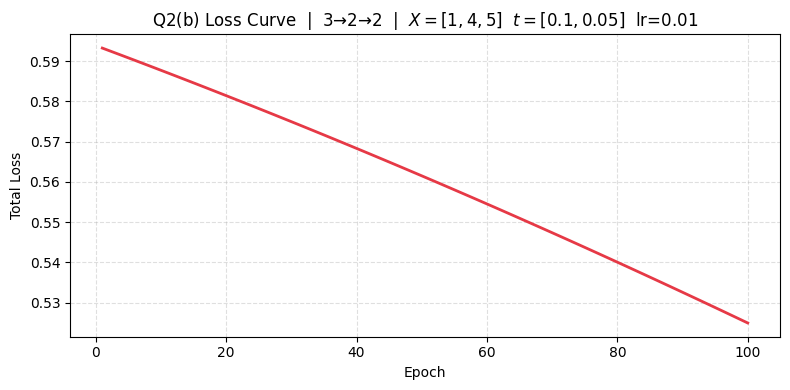

In [ ]:
"""
===================================================================
  FULLY AUTOMATED ANN  —  Generalised Backpropagation
  User specifies at runtime:
    1. Number of inputs
    2. Number of hidden layers
    3. Number of neurons in each hidden layer
    4. Number of outputs
    5. Number of epochs
    + Learning rate, activations, weight init mode
===================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

# ─────────────────────────────────────────────────────────────────
#  ACTIVATION FUNCTIONS
# ─────────────────────────────────────────────────────────────────
def sigmoid(z):     return 1.0 / (1.0 + np.exp(-z))
def sigmoid_d(a):   return a * (1.0 - a)

def relu(z):        return np.maximum(0.0, z)
def relu_d(a):      return (a > 0).astype(float)

def tanh_fn(z):     return np.tanh(z)
def tanh_d(a):      return 1.0 - a ** 2

def linear(z):      return z
def linear_d(a):    return np.ones_like(a)

ACTIVATIONS = {
    "sigmoid": (sigmoid, sigmoid_d),
    "relu"   : (relu,    relu_d),
    "tanh"   : (tanh_fn, tanh_d),
    "linear" : (linear,  linear_d),
}


# ─────────────────────────────────────────────────────────────────
#  ANN CLASS
# ─────────────────────────────────────────────────────────────────
class ANN:
    """
    Parameters
    ----------
    layer_sizes   : list[int]   e.g. [3, 2, 2]
    activations   : list[str]   one per non-input layer
    learning_rate : float
    weight_init   : "random" | "xavier" | "given"
    init_weights  : dict {"W": [...], "b": [...]}  (only for "given")
    seed          : int
    """

    def __init__(self, layer_sizes, activations,
                 learning_rate=0.01,
                 weight_init="random",
                 init_weights=None,
                 seed=42):

        assert len(activations) == len(layer_sizes) - 1
        self.L   = len(layer_sizes) - 1
        self.act = [ACTIVATIONS[a] for a in activations]
        self.lr  = learning_rate
        rng      = np.random.default_rng(seed)

        if weight_init == "given" and init_weights is not None:
            self.W = [np.array(w, dtype=float) for w in init_weights["W"]]
            self.b = [np.array(b, dtype=float).reshape(-1) for b in init_weights["b"]]
        elif weight_init == "xavier":
            self.W, self.b = [], []
            for i in range(self.L):
                std = np.sqrt(2.0 / (layer_sizes[i] + layer_sizes[i+1]))
                self.W.append(rng.normal(0, std, (layer_sizes[i+1], layer_sizes[i])))
                self.b.append(np.zeros(layer_sizes[i+1]))
        else:
            self.W, self.b = [], []
            for i in range(self.L):
                self.W.append(rng.uniform(-0.5, 0.5,
                              (layer_sizes[i+1], layer_sizes[i])))
                self.b.append(np.zeros(layer_sizes[i+1]))

        self.W_init = deepcopy(self.W)
        self.b_init = deepcopy(self.b)

    # ── Forward ──────────────────────────────────────────────────
    def forward(self, x):
        a = [np.array(x, dtype=float)]
        z_list = []
        for l in range(self.L):
            z = self.W[l] @ a[l] + self.b[l]
            z_list.append(z)
            a.append(self.act[l][0](z))
        self._a = a
        self._z = z_list
        return a[-1]

    # ── Loss ─────────────────────────────────────────────────────
    def loss(self, output, target):
        return 0.5 * np.sum((np.array(target, float) - output) ** 2)

    # ── Backward ─────────────────────────────────────────────────
    def backward(self, target):
        t     = np.array(target, float)
        a     = self._a
        delta = (a[-1] - t) * self.act[-1][1](a[-1])
        dW    = [None] * self.L
        db    = [None] * self.L
        for l in reversed(range(self.L)):
            dW[l] = np.outer(delta, a[l])
            db[l] = delta.copy()
            if l > 0:
                delta = (self.W[l].T @ delta) * self.act[l-1][1](a[l])
        for l in range(self.L):
            self.W[l] -= self.lr * dW[l]
            self.b[l] -= self.lr * db[l]
        self._dW = dW
        self._db = db

    # ── One detailed pass ─────────────────────────────────────────
    def print_one_pass(self, x, target):
        x = np.array(x, float);  t = np.array(target, float)

        print("\n" + "="*62)
        print("  FORWARD PASS  (Step-by-step)")
        print("="*62)
        out = self.forward(x)
        for l in range(self.L):
            lbl = "Hidden" if l < self.L - 1 else "Output"
            print(f"\n  ── {lbl} Layer {l+1} ──")
            for i in range(len(self._a[l+1])):
                terms = " + ".join(
                    f"{self.W_init[l][i,j]:.4f}·{self._a[l][j]:.4f}"
                    for j in range(len(self._a[l]))
                )
                print(f"  net[{l+1}][{i}] = {terms} + b={self.b_init[l][i]:.4f}"
                      f"  =  {self._z[l][i]:.6f}")
                print(f"  out[{l+1}][{i}] = act({self._z[l][i]:.6f})"
                      f"  =  {self._a[l+1][i]:.6f}")

        total_loss = self.loss(out, t)
        print(f"\n  Predicted : {np.round(out, 6)}")
        print(f"  Target    : {t}")
        for i in range(len(t)):
            e = 0.5*(t[i]-out[i])**2
            print(f"  E_out[{i}]  = 0.5·({t[i]:.4f} - {out[i]:.6f})²"
                  f"  =  {e:.8f}")
        print(f"  E_total   =  {total_loss:.8f}")

        print("\n" + "="*62)
        print("  BACKWARD PASS  (Gradients → Updated Weights)")
        print("="*62)
        self.backward(t)
        for l in reversed(range(self.L)):
            lbl = "Hidden" if l < self.L - 1 else "Output"
            print(f"\n  ── {lbl} Layer {l+1} ──")
            for i in range(self.W[l].shape[0]):
                for j in range(self.W[l].shape[1]):
                    old = self.W_init[l][i, j]
                    new = self.W[l][i, j]
                    grad = self._dW[l][i, j]
                    print(f"  W[{l+1}][{i},{j}]  grad={grad:+.8f}"
                          f"   {old:.6f} → {new:.8f}")

    # ── Train N epochs ────────────────────────────────────────────
    def train(self, x, target, epochs=100, verbose=True, print_every=10):
        losses = []
        for ep in range(1, epochs + 1):
            out  = self.forward(x)
            err  = self.loss(out, target)
            losses.append(err)
            self.backward(target)
            if verbose and (ep == 1 or ep % print_every == 0 or ep == epochs):
                print(f"  Epoch {ep:5d}  |  Loss = {err:.8f}"
                      f"  |  Output = {np.round(out, 5)}")
        return losses

    # ── Weight summary ────────────────────────────────────────────
    def print_weights(self, label="Weights"):
        print(f"\n{'─'*62}\n  {label}\n{'─'*62}")
        for l in range(self.L):
            lbl = "Hidden" if l < self.L - 1 else "Output"
            print(f"\n  {lbl} Layer {l+1}  — W shape {self.W[l].shape}")
            for i in range(self.W[l].shape[0]):
                for j in range(self.W[l].shape[1]):
                    print(f"    W[{l+1}][{i},{j}]  "
                          f"init={self.W_init[l][i,j]:.6f}  →  "
                          f"final={self.W[l][i,j]:.8f}")
            print(f"  Bias {l+1} : init={np.round(self.b_init[l],4)}"
                  f"  →  final={np.round(self.b[l],6)}")


# ─────────────────────────────────────────────────────────────────
#  INTERACTIVE INPUT HELPER
# ─────────────────────────────────────────────────────────────────
def get_float_list(prompt, n):
    """Ask user to enter exactly n floats."""
    while True:
        try:
            vals = list(map(float, input(prompt).split()))
            if len(vals) == n:
                return vals
            print(f"  ✗  Please enter exactly {n} values.")
        except ValueError:
            print("  ✗  Invalid input, use numbers separated by spaces.")

def get_int(prompt, lo=1, hi=10000):
    while True:
        try:
            v = int(input(prompt))
            if lo <= v <= hi:
                return v
            print(f"  ✗  Enter a value between {lo} and {hi}.")
        except ValueError:
            print("  ✗  Please enter an integer.")

def get_activation(prompt):
    opts = list(ACTIVATIONS.keys())
    while True:
        v = input(prompt).strip().lower()
        if v in opts:
            return v
        print(f"  ✗  Choose from: {opts}")

def get_choice(prompt, opts):
    while True:
        v = input(prompt).strip().lower()
        if v in opts:
            return v
        print(f"  ✗  Choose from: {opts}")


# ─────────────────────────────────────────────────────────────────
#  MAIN — interactive or demo
# ─────────────────────────────────────────────────────────────────
def run_interactive():
    print("\n" + "█"*62)
    print("  AUTOMATED ANN BUILDER  —  Define Your Network")
    print("█"*62)

    # 1. Number of inputs
    n_in = get_int("\n[1] Number of inputs           : ", 1, 100)

    # 2. Number of hidden layers
    n_hidden = get_int("[2] Number of hidden layers    : ", 1, 20)

    # 3. Neurons in each hidden layer
    hidden_sizes = []
    for i in range(n_hidden):
        h = get_int(f"    Neurons in hidden layer {i+1}  : ", 1, 512)
        hidden_sizes.append(h)

    # 4. Number of outputs
    n_out = get_int("[4] Number of outputs          : ", 1, 100)

    # 5. Number of epochs
    epochs = get_int("[5] Number of epochs           : ", 1, 100000)

    # Learning rate
    while True:
        try:
            lr = float(input("[6] Learning rate (e.g. 0.01)  : "))
            if lr > 0: break
            print("  ✗  Must be positive.")
        except ValueError:
            print("  ✗  Enter a float.")

    # Activations
    print(f"\n    Available activations: {list(ACTIVATIONS.keys())}")
    acts = []
    for i in range(n_hidden):
        a = get_activation(f"    Activation for hidden layer {i+1}: ")
        acts.append(a)
    out_act = get_activation(f"    Activation for output layer   : ")
    acts.append(out_act)

    # Weight init
    init_mode = get_choice(
        "\n[7] Weight init  [random / xavier] : ", ["random", "xavier"])

    # Build layer_sizes
    layer_sizes = [n_in] + hidden_sizes + [n_out]

    print(f"\n  Architecture : {' → '.join(map(str, layer_sizes))}")
    print(f"  Activations  : {acts}")
    print(f"  LR={lr}   Epochs={epochs}   Init={init_mode}")

    # Input values
    print(f"\n  Enter {n_in} input value(s):")
    X = get_float_list(f"    X (space-separated, {n_in} values): ", n_in)

    # Target values
    print(f"  Enter {n_out} target value(s):")
    T = get_float_list(f"    T (space-separated, {n_out} values): ", n_out)

    # Build and run
    net = ANN(layer_sizes, acts, lr, init_mode)

    # One detailed pass
    print("\n" + "─"*62)
    print("  ONE FORWARD + BACKWARD PASS  (before training)")
    print("─"*62)
    net.print_one_pass(X, T)

    # Reset and train
    net.W = deepcopy(net.W_init)
    net.b = deepcopy(net.b_init)

    print(f"\n{'─'*62}")
    print(f"  TRAINING  for {epochs} epoch(s)")
    print(f"{'─'*62}")
    pe = max(1, epochs // 10)
    losses = net.train(X, T, epochs=epochs, verbose=True, print_every=pe)

    net.print_weights("Final Weights")

    # Loss curve
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, epochs+1), losses, color="#e63946", linewidth=2)
    plt.xlabel("Epoch"); plt.ylabel("Total Loss")
    plt.title(f"Loss Curve  |  Architecture: {' → '.join(map(str, layer_sizes))}\n"
              f"LR={lr}  |  Epochs={epochs}  |  Activations={acts}")
    plt.grid(True, linestyle="--", alpha=0.4); plt.tight_layout()
    plt.savefig("loss_curve_custom.png", dpi=150)
    print("\n  ✓ Loss curve saved to loss_curve_custom.png")
    plt.show()


def run_q2b_demo():
    """Reproduce Q2(b) Figure 1 exactly — no user input needed."""
    print("\n" + "█"*62)
    print("  Q2(b) DEMO  :  Architecture  3 → 2 → 2  (Figure 1)")
    print("█"*62)

    layer_sizes = [3, 2, 2]
    activations = ["sigmoid", "sigmoid"]

    W_h = np.array([[0.1, 0.3, 0.5],
                    [0.2, 0.4, 0.6]])
    W_o = np.array([[0.7, 0.9],
                    [0.8, 0.1]])
    b_h = np.array([0.5, 0.5])
    b_o = np.array([0.5, 0.5])

    net = ANN(layer_sizes, activations,
              learning_rate=0.01,
              weight_init="given",
              init_weights={"W": [W_h, W_o], "b": [b_h, b_o]})

    X      = [1.0, 4.0, 5.0]
    target = [0.1, 0.05]

    net.print_one_pass(X, target)

    # Reset for clean training run
    net.W = deepcopy(net.W_init)
    net.b = deepcopy(net.b_init)

    epochs = 100
    print(f"\n{'─'*62}")
    print(f"  TRAINING  for {epochs} epochs")
    print(f"{'─'*62}")
    losses = net.train(X, target, epochs=epochs, verbose=True, print_every=10)
    net.print_weights("Final Weights after 100 epochs")

    plt.figure(figsize=(8, 4))
    plt.plot(range(1, epochs+1), losses, color="#e63946", linewidth=2)
    plt.xlabel("Epoch"); plt.ylabel("Total Loss")
    plt.title(r"Q2(b) Loss Curve  |  3→2→2  |  $X=[1,4,5]$  "
              r"$t=[0.1, 0.05]$  lr=0.01")
    plt.grid(True, linestyle="--", alpha=0.4); plt.tight_layout()
    plt.savefig("loss_curve_q2b.png", dpi=150)
    print("\n  ✓ Loss curve saved to loss_curve_q2b.png")
    plt.show()


# ─────────────────────────────────────────────────────────────────
#  ENTRY POINT
# ─────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("\n" + "="*62)
    print("  SELECT MODE")
    print("="*62)
    print("  [1]  Q2(b) demo  — runs Figure 1 automatically")
    print("  [2]  Custom ANN  — you define everything interactively")
    mode = get_choice("\n  Enter 1 or 2 : ", ["1", "2"])

    if mode == "1":
        run_q2b_demo()
    else:
        run_interactive()

### *Code - Custom ANN Output*


  SELECT MODE
  [1]  Q2(b) demo  — runs Figure 1 automatically
  [2]  Custom ANN  — you define everything interactively

  Enter 1 or 2 : 2

██████████████████████████████████████████████████████████████
  AUTOMATED ANN BUILDER  —  Define Your Network
██████████████████████████████████████████████████████████████

[1] Number of inputs           : 3
[2] Number of hidden layers    : 2
    Neurons in hidden layer 1  : 4
    Neurons in hidden layer 2  : 3
[4] Number of outputs          : 2
[5] Number of epochs           : 100
[6] Learning rate (e.g. 0.01)  : 0.01

    Available activations: ['sigmoid', 'relu', 'tanh', 'linear']
    Activation for hidden layer 1: relu
    Activation for hidden layer 2: tanh
    Activation for output layer   : sigmoid

[7] Weight init  [random / xavier] : random

  Architecture : 3 → 4 → 3 → 2
  Activations  : ['relu', 'tanh', 'sigmoid']
  LR=0.01   Epochs=100   Init=random

  Enter 3 input value(s):
    X (space-separated, 3 values): 1 2 3
  Enter 2 target

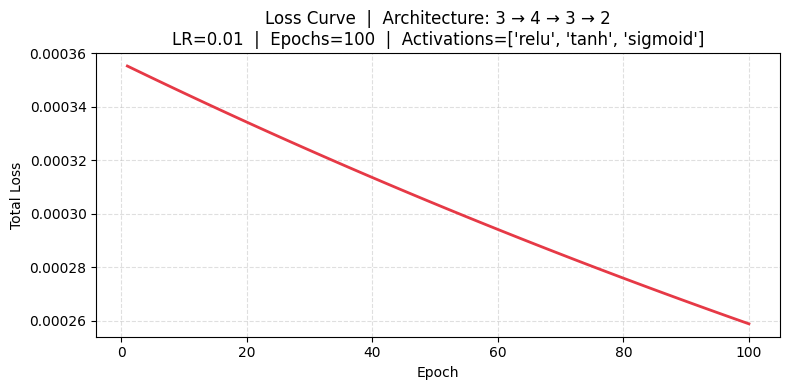

In [ ]:
"""
===================================================================
  FULLY AUTOMATED ANN  —  Generalised Backpropagation
  User specifies at runtime:
    1. Number of inputs
    2. Number of hidden layers
    3. Number of neurons in each hidden layer
    4. Number of outputs
    5. Number of epochs
    + Learning rate, activations, weight init mode
===================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

# ─────────────────────────────────────────────────────────────────
#  ACTIVATION FUNCTIONS
# ─────────────────────────────────────────────────────────────────
def sigmoid(z):     return 1.0 / (1.0 + np.exp(-z))
def sigmoid_d(a):   return a * (1.0 - a)

def relu(z):        return np.maximum(0.0, z)
def relu_d(a):      return (a > 0).astype(float)

def tanh_fn(z):     return np.tanh(z)
def tanh_d(a):      return 1.0 - a ** 2

def linear(z):      return z
def linear_d(a):    return np.ones_like(a)

ACTIVATIONS = {
    "sigmoid": (sigmoid, sigmoid_d),
    "relu"   : (relu,    relu_d),
    "tanh"   : (tanh_fn, tanh_d),
    "linear" : (linear,  linear_d),
}


# ─────────────────────────────────────────────────────────────────
#  ANN CLASS
# ─────────────────────────────────────────────────────────────────
class ANN:
    """
    Parameters
    ----------
    layer_sizes   : list[int]   e.g. [3, 2, 2]
    activations   : list[str]   one per non-input layer
    learning_rate : float
    weight_init   : "random" | "xavier" | "given"
    init_weights  : dict {"W": [...], "b": [...]}  (only for "given")
    seed          : int
    """

    def __init__(self, layer_sizes, activations,
                 learning_rate=0.01,
                 weight_init="random",
                 init_weights=None,
                 seed=42):

        assert len(activations) == len(layer_sizes) - 1
        self.L   = len(layer_sizes) - 1
        self.act = [ACTIVATIONS[a] for a in activations]
        self.lr  = learning_rate
        rng      = np.random.default_rng(seed)

        if weight_init == "given" and init_weights is not None:
            self.W = [np.array(w, dtype=float) for w in init_weights["W"]]
            self.b = [np.array(b, dtype=float).reshape(-1) for b in init_weights["b"]]
        elif weight_init == "xavier":
            self.W, self.b = [], []
            for i in range(self.L):
                std = np.sqrt(2.0 / (layer_sizes[i] + layer_sizes[i+1]))
                self.W.append(rng.normal(0, std, (layer_sizes[i+1], layer_sizes[i])))
                self.b.append(np.zeros(layer_sizes[i+1]))
        else:
            self.W, self.b = [], []
            for i in range(self.L):
                self.W.append(rng.uniform(-0.5, 0.5,
                              (layer_sizes[i+1], layer_sizes[i])))
                self.b.append(np.zeros(layer_sizes[i+1]))

        self.W_init = deepcopy(self.W)
        self.b_init = deepcopy(self.b)

    # ── Forward ──────────────────────────────────────────────────
    def forward(self, x):
        a = [np.array(x, dtype=float)]
        z_list = []
        for l in range(self.L):
            z = self.W[l] @ a[l] + self.b[l]
            z_list.append(z)
            a.append(self.act[l][0](z))
        self._a = a
        self._z = z_list
        return a[-1]

    # ── Loss ─────────────────────────────────────────────────────
    def loss(self, output, target):
        return 0.5 * np.sum((np.array(target, float) - output) ** 2)

    # ── Backward ─────────────────────────────────────────────────
    def backward(self, target):
        t     = np.array(target, float)
        a     = self._a
        delta = (a[-1] - t) * self.act[-1][1](a[-1])
        dW    = [None] * self.L
        db    = [None] * self.L
        for l in reversed(range(self.L)):
            dW[l] = np.outer(delta, a[l])
            db[l] = delta.copy()
            if l > 0:
                delta = (self.W[l].T @ delta) * self.act[l-1][1](a[l])
        for l in range(self.L):
            self.W[l] -= self.lr * dW[l]
            self.b[l] -= self.lr * db[l]
        self._dW = dW
        self._db = db

    # ── One detailed pass ─────────────────────────────────────────
    def print_one_pass(self, x, target):
        x = np.array(x, float);  t = np.array(target, float)

        print("\n" + "="*62)
        print("  FORWARD PASS  (Step-by-step)")
        print("="*62)
        out = self.forward(x)
        for l in range(self.L):
            lbl = "Hidden" if l < self.L - 1 else "Output"
            print(f"\n  ── {lbl} Layer {l+1} ──")
            for i in range(len(self._a[l+1])):
                terms = " + ".join(
                    f"{self.W_init[l][i,j]:.4f}·{self._a[l][j]:.4f}"
                    for j in range(len(self._a[l]))
                )
                print(f"  net[{l+1}][{i}] = {terms} + b={self.b_init[l][i]:.4f}"
                      f"  =  {self._z[l][i]:.6f}")
                print(f"  out[{l+1}][{i}] = act({self._z[l][i]:.6f})"
                      f"  =  {self._a[l+1][i]:.6f}")

        total_loss = self.loss(out, t)
        print(f"\n  Predicted : {np.round(out, 6)}")
        print(f"  Target    : {t}")
        for i in range(len(t)):
            e = 0.5*(t[i]-out[i])**2
            print(f"  E_out[{i}]  = 0.5·({t[i]:.4f} - {out[i]:.6f})²"
                  f"  =  {e:.8f}")
        print(f"  E_total   =  {total_loss:.8f}")

        print("\n" + "="*62)
        print("  BACKWARD PASS  (Gradients → Updated Weights)")
        print("="*62)
        self.backward(t)
        for l in reversed(range(self.L)):
            lbl = "Hidden" if l < self.L - 1 else "Output"
            print(f"\n  ── {lbl} Layer {l+1} ──")
            for i in range(self.W[l].shape[0]):
                for j in range(self.W[l].shape[1]):
                    old = self.W_init[l][i, j]
                    new = self.W[l][i, j]
                    grad = self._dW[l][i, j]
                    print(f"  W[{l+1}][{i},{j}]  grad={grad:+.8f}"
                          f"   {old:.6f} → {new:.8f}")

    # ── Train N epochs ────────────────────────────────────────────
    def train(self, x, target, epochs=100, verbose=True, print_every=10):
        losses = []
        for ep in range(1, epochs + 1):
            out  = self.forward(x)
            err  = self.loss(out, target)
            losses.append(err)
            self.backward(target)
            if verbose and (ep == 1 or ep % print_every == 0 or ep == epochs):
                print(f"  Epoch {ep:5d}  |  Loss = {err:.8f}"
                      f"  |  Output = {np.round(out, 5)}")
        return losses

    # ── Weight summary ────────────────────────────────────────────
    def print_weights(self, label="Weights"):
        print(f"\n{'─'*62}\n  {label}\n{'─'*62}")
        for l in range(self.L):
            lbl = "Hidden" if l < self.L - 1 else "Output"
            print(f"\n  {lbl} Layer {l+1}  — W shape {self.W[l].shape}")
            for i in range(self.W[l].shape[0]):
                for j in range(self.W[l].shape[1]):
                    print(f"    W[{l+1}][{i},{j}]  "
                          f"init={self.W_init[l][i,j]:.6f}  →  "
                          f"final={self.W[l][i,j]:.8f}")
            print(f"  Bias {l+1} : init={np.round(self.b_init[l],4)}"
                  f"  →  final={np.round(self.b[l],6)}")


# ─────────────────────────────────────────────────────────────────
#  INTERACTIVE INPUT HELPER
# ─────────────────────────────────────────────────────────────────
def get_float_list(prompt, n):
    """Ask user to enter exactly n floats."""
    while True:
        try:
            vals = list(map(float, input(prompt).split()))
            if len(vals) == n:
                return vals
            print(f"  ✗  Please enter exactly {n} values.")
        except ValueError:
            print("  ✗  Invalid input, use numbers separated by spaces.")

def get_int(prompt, lo=1, hi=10000):
    while True:
        try:
            v = int(input(prompt))
            if lo <= v <= hi:
                return v
            print(f"  ✗  Enter a value between {lo} and {hi}.")
        except ValueError:
            print("  ✗  Please enter an integer.")

def get_activation(prompt):
    opts = list(ACTIVATIONS.keys())
    while True:
        v = input(prompt).strip().lower()
        if v in opts:
            return v
        print(f"  ✗  Choose from: {opts}")

def get_choice(prompt, opts):
    while True:
        v = input(prompt).strip().lower()
        if v in opts:
            return v
        print(f"  ✗  Choose from: {opts}")


# ─────────────────────────────────────────────────────────────────
#  MAIN — interactive or demo
# ─────────────────────────────────────────────────────────────────
def run_interactive():
    print("\n" + "█"*62)
    print("  AUTOMATED ANN BUILDER  —  Define Your Network")
    print("█"*62)

    # 1. Number of inputs
    n_in = get_int("\n[1] Number of inputs           : ", 1, 100)

    # 2. Number of hidden layers
    n_hidden = get_int("[2] Number of hidden layers    : ", 1, 20)

    # 3. Neurons in each hidden layer
    hidden_sizes = []
    for i in range(n_hidden):
        h = get_int(f"    Neurons in hidden layer {i+1}  : ", 1, 512)
        hidden_sizes.append(h)

    # 4. Number of outputs
    n_out = get_int("[4] Number of outputs          : ", 1, 100)

    # 5. Number of epochs
    epochs = get_int("[5] Number of epochs           : ", 1, 100000)

    # Learning rate
    while True:
        try:
            lr = float(input("[6] Learning rate (e.g. 0.01)  : "))
            if lr > 0: break
            print("  ✗  Must be positive.")
        except ValueError:
            print("  ✗  Enter a float.")

    # Activations
    print(f"\n    Available activations: {list(ACTIVATIONS.keys())}")
    acts = []
    for i in range(n_hidden):
        a = get_activation(f"    Activation for hidden layer {i+1}: ")
        acts.append(a)
    out_act = get_activation(f"    Activation for output layer   : ")
    acts.append(out_act)

    # Weight init
    init_mode = get_choice(
        "\n[7] Weight init  [random / xavier] : ", ["random", "xavier"])

    # Build layer_sizes
    layer_sizes = [n_in] + hidden_sizes + [n_out]

    print(f"\n  Architecture : {' → '.join(map(str, layer_sizes))}")
    print(f"  Activations  : {acts}")
    print(f"  LR={lr}   Epochs={epochs}   Init={init_mode}")

    # Input values
    print(f"\n  Enter {n_in} input value(s):")
    X = get_float_list(f"    X (space-separated, {n_in} values): ", n_in)

    # Target values
    print(f"  Enter {n_out} target value(s):")
    T = get_float_list(f"    T (space-separated, {n_out} values): ", n_out)

    # Build and run
    net = ANN(layer_sizes, acts, lr, init_mode)

    # One detailed pass
    print("\n" + "─"*62)
    print("  ONE FORWARD + BACKWARD PASS  (before training)")
    print("─"*62)
    net.print_one_pass(X, T)

    # Reset and train
    net.W = deepcopy(net.W_init)
    net.b = deepcopy(net.b_init)

    print(f"\n{'─'*62}")
    print(f"  TRAINING  for {epochs} epoch(s)")
    print(f"{'─'*62}")
    pe = max(1, epochs // 10)
    losses = net.train(X, T, epochs=epochs, verbose=True, print_every=pe)

    net.print_weights("Final Weights")

    # Loss curve
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, epochs+1), losses, color="#e63946", linewidth=2)
    plt.xlabel("Epoch"); plt.ylabel("Total Loss")
    plt.title(f"Loss Curve  |  Architecture: {' → '.join(map(str, layer_sizes))}\n"
              f"LR={lr}  |  Epochs={epochs}  |  Activations={acts}")
    plt.grid(True, linestyle="--", alpha=0.4); plt.tight_layout()
    plt.savefig("loss_curve_custom.png", dpi=150)
    print("\n  ✓ Loss curve saved to loss_curve_custom.png")
    plt.show()


def run_q2b_demo():
    """Reproduce Q2(b) Figure 1 exactly — no user input needed."""
    print("\n" + "█"*62)
    print("  Q2(b) DEMO  :  Architecture  3 → 2 → 2  (Figure 1)")
    print("█"*62)

    layer_sizes = [3, 2, 2]
    activations = ["sigmoid", "sigmoid"]

    W_h = np.array([[0.1, 0.3, 0.5],
                    [0.2, 0.4, 0.6]])
    W_o = np.array([[0.7, 0.9],
                    [0.8, 0.1]])
    b_h = np.array([0.5, 0.5])
    b_o = np.array([0.5, 0.5])

    net = ANN(layer_sizes, activations,
              learning_rate=0.01,
              weight_init="given",
              init_weights={"W": [W_h, W_o], "b": [b_h, b_o]})

    X      = [1.0, 4.0, 5.0]
    target = [0.1, 0.05]

    net.print_one_pass(X, target)

    # Reset for clean training run
    net.W = deepcopy(net.W_init)
    net.b = deepcopy(net.b_init)

    epochs = 100
    print(f"\n{'─'*62}")
    print(f"  TRAINING  for {epochs} epochs")
    print(f"{'─'*62}")
    losses = net.train(X, target, epochs=epochs, verbose=True, print_every=10)
    net.print_weights("Final Weights after 100 epochs")

    plt.figure(figsize=(8, 4))
    plt.plot(range(1, epochs+1), losses, color="#e63946", linewidth=2)
    plt.xlabel("Epoch"); plt.ylabel("Total Loss")
    plt.title(r"Q2(b) Loss Curve  |  3→2→2  |  $X=[1,4,5]$  "
              r"$t=[0.1, 0.05]$  lr=0.01")
    plt.grid(True, linestyle="--", alpha=0.4); plt.tight_layout()
    plt.savefig("loss_curve_q2b.png", dpi=150)
    print("\n  ✓ Loss curve saved to loss_curve_q2b.png")
    plt.show()


# ─────────────────────────────────────────────────────────────────
#  ENTRY POINT
# ─────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("\n" + "="*62)
    print("  SELECT MODE")
    print("="*62)
    print("  [1]  Q2(b) demo  — runs Figure 1 automatically")
    print("  [2]  Custom ANN  — you define everything interactively")
    mode = get_choice("\n  Enter 1 or 2 : ", ["1", "2"])

    if mode == "1":
        run_q2b_demo()
    else:
        run_interactive()

### *Explanation*

The implemented code automates the construction and training of an Artificial Neural Network by allowing the user to dynamically define the network architecture at runtime. Instead of hardcoding parameters, the user specifies the number of input neurons, hidden layers, neurons in each hidden layer, output neurons, and training epochs. Based on these inputs, the program automatically builds the network structure, initializes weights (using random or Xavier initialization), and assigns activation functions for each layer. This makes the model highly flexible and adaptable to different problem configurations.

In addition to architecture automation, the training process is also fully automated using the backpropagation algorithm. The code performs forward propagation to compute outputs, calculates error using a loss function, and updates weights and biases through gradient descent during each epoch. It also provides detailed step-by-step computation for one iteration and visualizes the learning process using a loss curve. This automation eliminates manual calculations and enables efficient experimentation with different ANN configurations